In [22]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

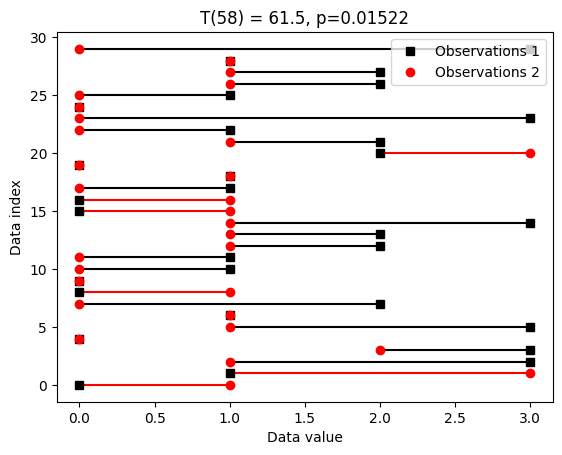

In [23]:
n = 30

observations_1 = np.random.poisson(1.5, n)
observations_2 = np.random.poisson(1, n)

t, p = stats.wilcoxon(observations_1, observations_2)

for index, (sample1, sample2) in enumerate(zip(observations_1, observations_2)):
    plt.plot([sample1, sample2], [index, index], 'kr'[int(sample1 < sample2)])

plt.plot(observations_1, np.arange(n), 'ks', markerfacecolor='k', label='Observations 1')
plt.plot(observations_2, np.arange(n), 'ro', markerfacecolor='r', label='Observations 2')
plt.title(f"T({observations_1.size + observations_2.size - 2}) = {t}, p={np.round(p, 5)}")
plt.ylabel('Data index')
plt.xlabel('Data value')
plt.legend()

plt.show()

In [29]:
sample_sizes = np.arange(5, 51)
lambdas = np.linspace(1, 3, 40)

p_values = np.zeros((sample_sizes.size, lambdas.size))

for sample_index, sample_size in enumerate(sample_sizes):
    for lamb_index, lamb in enumerate(lambdas):

        obs_1 = np.random.poisson(lambdas[0], sample_size)
        obs_2 = np.random.poisson(lamb, sample_size)

        t, p = stats.wilcoxon(obs_1, obs_2)
        p_values[sample_index, lamb_index] = -np.log(p)


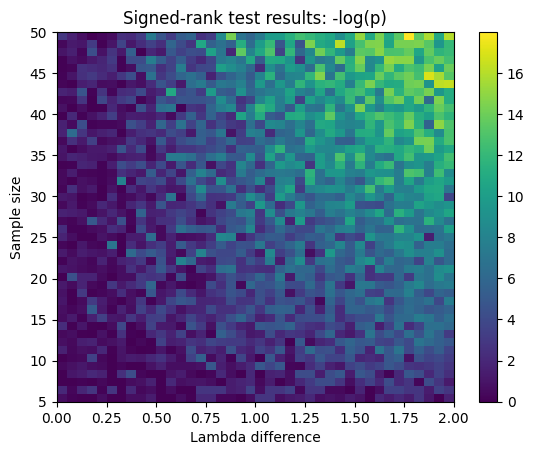

In [30]:

plt.imshow(p_values, origin='lower', extent=(lambdas[0]-1, lambdas[-1]-1, sample_sizes[0], sample_sizes[-1]), aspect='auto')
plt.colorbar()
plt.xlabel('Lambda difference')
plt.ylabel('Sample size')
plt.title('Signed-rank test results: -log(p)')

plt.show()